# Champions Predictor - Visualizaciones PRO 🎨

## Visualizaciones Profesionales
1. **Bracket Interactivo** - Torneo completo con probabilidades
2. **Heatmap de Enfrentamientos** - Matriz de probabilidades
3. **Sankey Diagram** - Flujo de equipos por rondas
4. **Radar Chart** - Comparación multidimensional top equipos
5. **Timeline Animado** - Evolución de probabilidades
6. **Treemap** - Concentración de probabilidades

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [2]:
# Cargar datos
df_prob = pd.read_csv('../data/processed/probabilidades_campeon.csv')
df_ratings = pd.read_csv('../data/processed/power_ratings_final.csv')

# Crear diccionario de ratings
ratings_dict = dict(zip(df_ratings['Equipo'], df_ratings['power_rating']))

print("✅ Datos cargados")

✅ Datos cargados


## 1. 🌳 BRACKET VISUAL INTERACTIVO

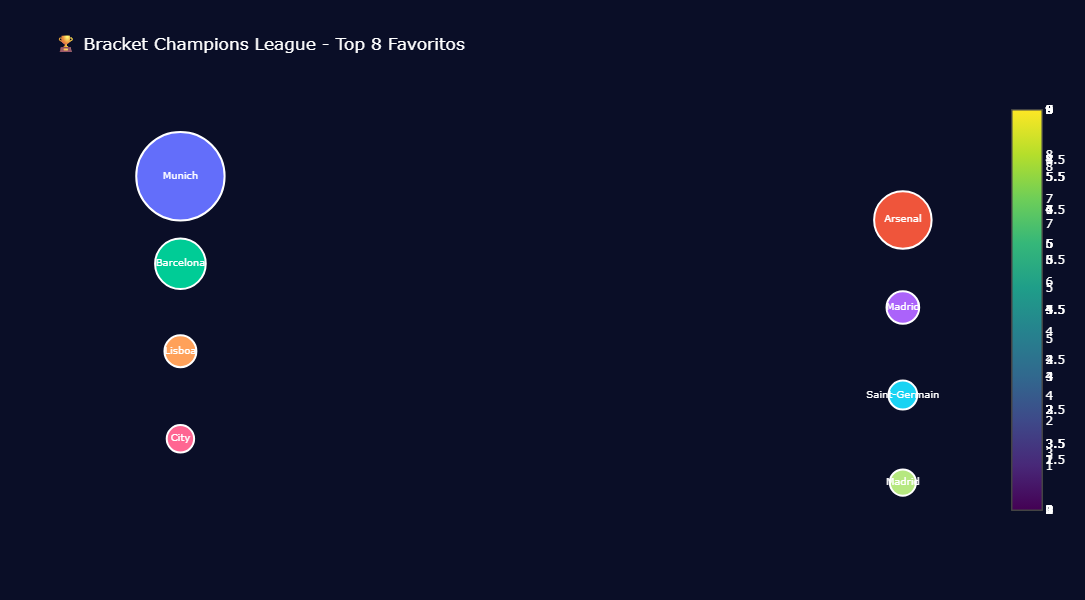

In [3]:
# Bracket simplificado con top 8 más probables
top_8 = df_prob.head(8)

fig_bracket = go.Figure()

# Posiciones en el bracket (x, y)
positions = {
    # Octavos (izquierda)
    'oct_1': (0, 7), 'oct_2': (0, 5), 'oct_3': (0, 3), 'oct_4': (0, 1),
    # Cuartos
    'qua_1': (1, 6), 'qua_2': (1, 2),
    # Semis
    'sem_1': (2, 4),
    # Final
    'final': (3, 4)
}

# Dibujar nodos (equipos)
for idx, row in top_8.iterrows():
    x_pos = idx % 2  # Alternar lados
    y_pos = 7 - idx
    
    # Tamaño según probabilidad
    size = 20 + row['Prob_Campeon'] * 2
    
    fig_bracket.add_trace(go.Scatter(
        x=[x_pos],
        y=[y_pos],
        mode='markers+text',
        marker=dict(
            size=size,
            color=row['Prob_Campeon'],
            colorscale='Viridis',
            line=dict(width=2, color='white'),
            showscale=True
        ),
        text=row['Equipo'].split()[-1],  # Solo apellido
        textposition='middle center',
        textfont=dict(color='white', size=10),
        hovertemplate=f"<b>{row['Equipo']}</b><br>" +
                      f"Prob Campeón: {row['Prob_Campeon']:.1f}%<br>" +
                      f"Rating: {row['Rating']:.0f}<extra></extra>",
        showlegend=False
    ))

fig_bracket.update_layout(
    title='🏆 Bracket Champions League - Top 8 Favoritos',
    height=600,
    plot_bgcolor='#0a0e27',
    paper_bgcolor='#0a0e27',
    font=dict(color='white'),
    xaxis=dict(showgrid=False, showticklabels=False, zeroline=False),
    yaxis=dict(showgrid=False, showticklabels=False, zeroline=False)
)

fig_bracket.show()
fig_bracket.write_html('../visualizations/bracket_interactivo.html')

## 2. 🔥 HEATMAP DE ENFRENTAMIENTOS POTENCIALES

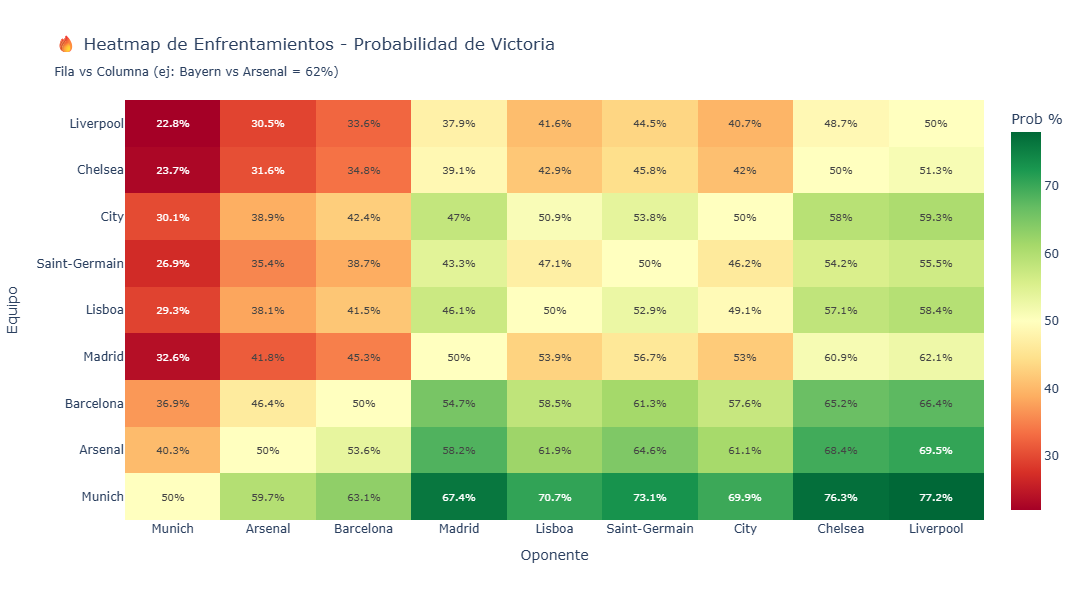

In [4]:
# Top 10 equipos
top_10_equipos = df_prob.head(10)['Equipo'].tolist()

# Calcular probabilidades de victoria para cada matchup
def calc_prob(eq1, eq2):
    r1 = ratings_dict[eq1]
    r2 = ratings_dict[eq2]
    return 1 / (1 + 10 ** ((r2 - r1) / 400)) * 100

# Crear matriz
matriz = []
for eq1 in top_10_equipos:
    fila = []
    for eq2 in top_10_equipos:
        if eq1 == eq2:
            fila.append(50)  # Diagonal
        else:
            fila.append(calc_prob(eq1, eq2))
    matriz.append(fila)

# Crear heatmap
fig_heatmap = go.Figure(data=go.Heatmap(
    z=matriz,
    x=[eq.split()[-1] for eq in top_10_equipos],  # Solo apellidos
    y=[eq.split()[-1] for eq in top_10_equipos],
    colorscale='RdYlGn',
    zmid=50,
    text=np.round(matriz, 1),
    texttemplate='%{text}%',
    textfont={"size": 10},
    colorbar=dict(title='Prob %')
))

fig_heatmap.update_layout(
    title='🔥 Heatmap de Enfrentamientos - Probabilidad de Victoria<br><sub>Fila vs Columna (ej: Bayern vs Arsenal = 62%)</sub>',
    xaxis_title='Oponente',
    yaxis_title='Equipo',
    height=600,
    width=800
)

fig_heatmap.show()
fig_heatmap.write_html('../visualizations/heatmap_enfrentamientos.html')

## 3. 📊 SANKEY DIAGRAM - FLUJO DE PROBABILIDADES

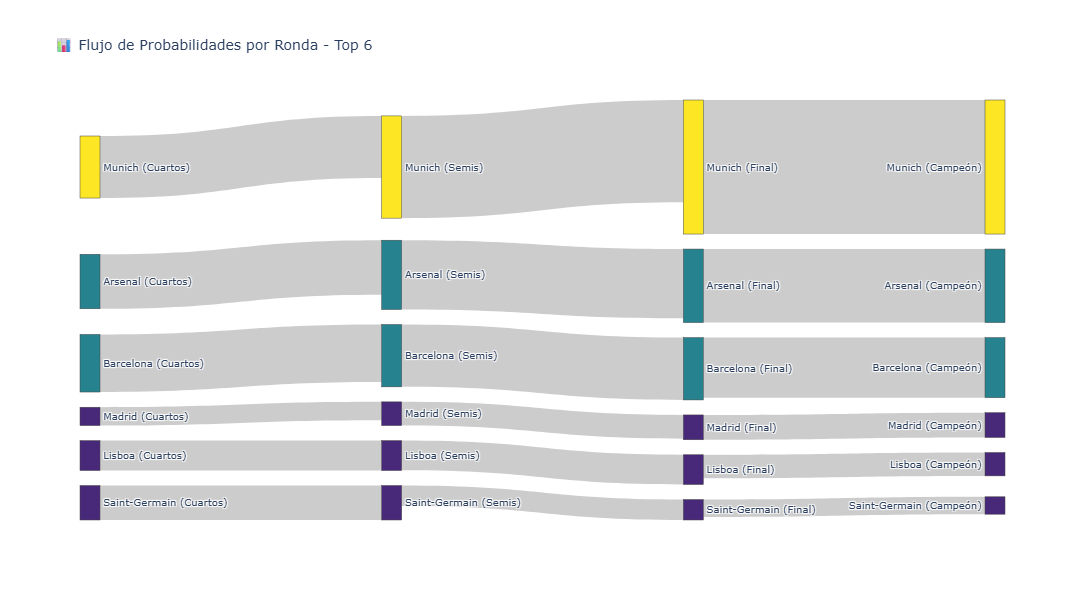

In [5]:
# Top 6 para no saturar
top_6 = df_prob.head(6)

# Nodos: Equipos en cada ronda
nodes = []
labels = []
colors = []

# Color scale
color_scale = px.colors.sequential.Viridis

# Crear nodos para cada ronda
for idx, row in top_6.iterrows():
    equipo = row['Equipo'].split()[-1]  # Apellido
    labels.extend([
        f"{equipo} (Cuartos)",
        f"{equipo} (Semis)",
        f"{equipo} (Final)",
        f"{equipo} (Campeón)"
    ])
    # Color degradado
    color_idx = int((row['Prob_Campeon'] / df_prob['Prob_Campeon'].max()) * (len(color_scale) - 1))
    team_color = color_scale[color_idx]
    colors.extend([team_color] * 4)

# Links: flujos entre rondas
sources = []
targets = []
values = []

for idx, row in top_6.iterrows():
    base_idx = idx * 4
    
    # Cuartos → Semis
    sources.append(base_idx)
    targets.append(base_idx + 1)
    values.append(row['Prob_Semi'])
    
    # Semis → Final
    sources.append(base_idx + 1)
    targets.append(base_idx + 2)
    values.append(row['Prob_Final'])
    
    # Final → Campeón
    sources.append(base_idx + 2)
    targets.append(base_idx + 3)
    values.append(row['Prob_Campeon'])

fig_sankey = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        label=labels,
        color=colors
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values
    )
)])

fig_sankey.update_layout(
    title='📊 Flujo de Probabilidades por Ronda - Top 6',
    font_size=10,
    height=600
)

fig_sankey.show()
fig_sankey.write_html('../visualizations/sankey_probabilidades.html')

## 4. 🎯 RADAR CHART - COMPARACIÓN MULTIDIMENSIONAL

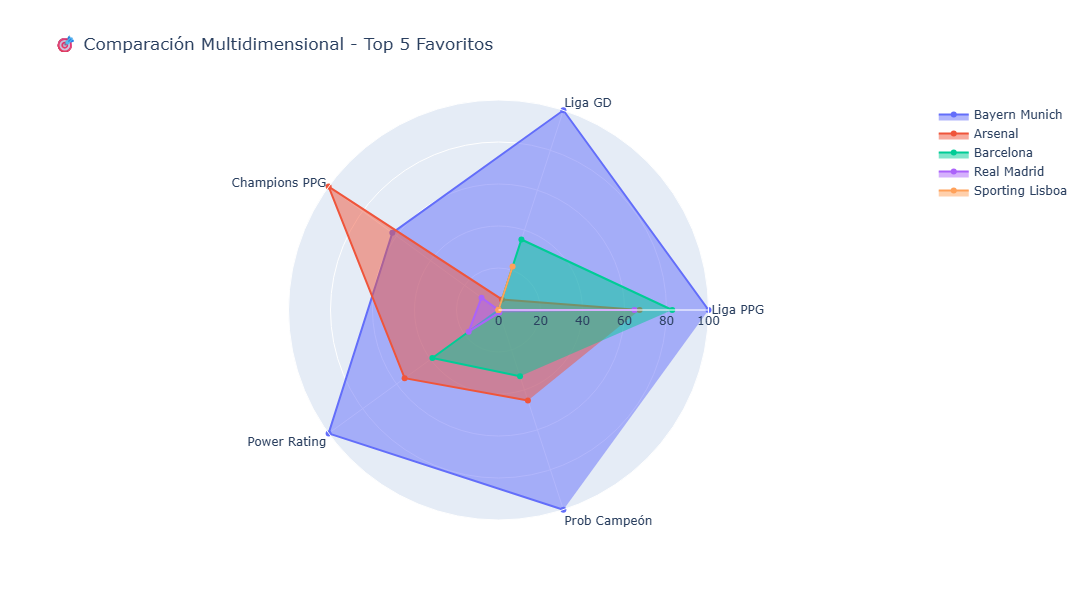

In [6]:
# Top 5 equipos
top_5 = df_prob.head(5)

# Unir con ratings para tener stats completas
top_5_full = top_5.merge(df_ratings[['Equipo', 'ppg_liga', 'gd_pg_liga', 'ppg_champions']], on='Equipo')

# Normalizar stats para radar (0-100)
def normalize_100(series):
    return ((series - series.min()) / (series.max() - series.min())) * 100

top_5_full['Liga_PPG_norm'] = normalize_100(top_5_full['ppg_liga'])
top_5_full['Liga_GD_norm'] = normalize_100(top_5_full['gd_pg_liga'])
top_5_full['Champions_PPG_norm'] = normalize_100(top_5_full['ppg_champions'])
top_5_full['Rating_norm'] = normalize_100(top_5_full['Rating'])
top_5_full['Prob_norm'] = normalize_100(top_5_full['Prob_Campeon'])

# Crear radar chart
fig_radar = go.Figure()

categories = ['Liga PPG', 'Liga GD', 'Champions PPG', 'Power Rating', 'Prob Campeón']

for idx, row in top_5_full.iterrows():
    fig_radar.add_trace(go.Scatterpolar(
        r=[
            row['Liga_PPG_norm'],
            row['Liga_GD_norm'],
            row['Champions_PPG_norm'],
            row['Rating_norm'],
            row['Prob_norm']
        ],
        theta=categories,
        fill='toself',
        name=row['Equipo']
    ))

fig_radar.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 100]
        )
    ),
    showlegend=True,
    title='🎯 Comparación Multidimensional - Top 5 Favoritos',
    height=600
)

fig_radar.show()
fig_radar.write_html('../visualizations/radar_comparacion.html')

## 5. 🌈 TREEMAP - CONCENTRACIÓN DE PROBABILIDADES

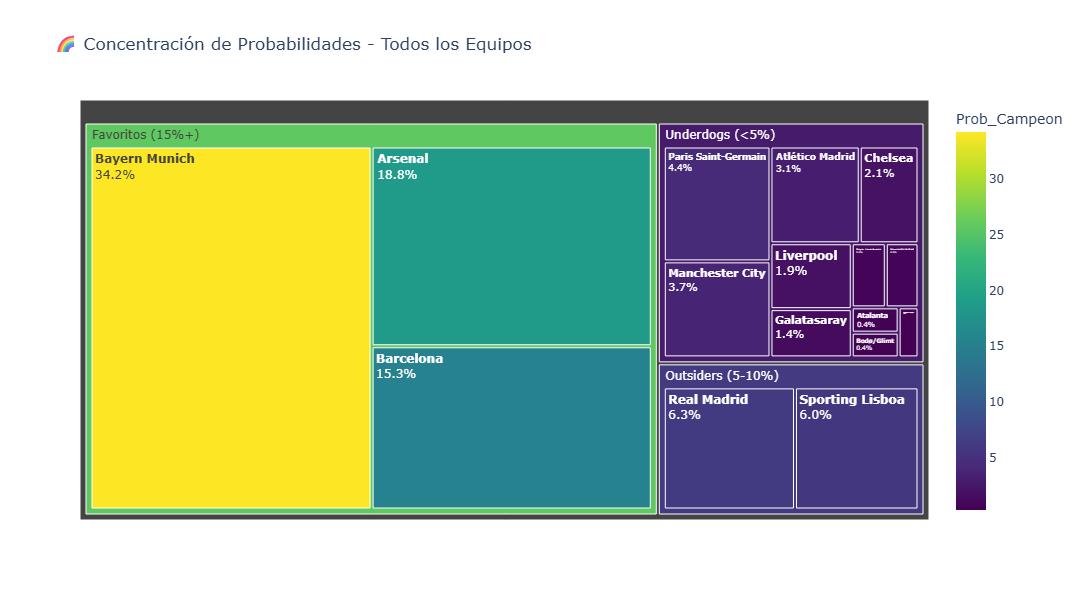

In [7]:
# Agrupar equipos por rangos de probabilidad
df_prob_copy = df_prob.copy()

def categorizar(prob):
    if prob >= 15:
        return 'Favoritos (15%+)'
    elif prob >= 10:
        return 'Contendientes (10-15%)'
    elif prob >= 5:
        return 'Outsiders (5-10%)'
    else:
        return 'Underdogs (<5%)'

df_prob_copy['Categoria'] = df_prob_copy['Prob_Campeon'].apply(categorizar)

# Treemap
fig_tree = px.treemap(
    df_prob_copy,
    path=['Categoria', 'Equipo'],
    values='Prob_Campeon',
    color='Prob_Campeon',
    color_continuous_scale='Viridis',
    title='🌈 Concentración de Probabilidades - Todos los Equipos'
)

fig_tree.update_traces(
    textinfo='label+value',
    texttemplate='<b>%{label}</b><br>%{value:.1f}%'
)

fig_tree.update_layout(height=600)

fig_tree.show()
fig_tree.write_html('../visualizations/treemap_concentracion.html')

## 6. 💎 GRÁFICO DE BURBUJAS 3D - Rating vs Prob vs Liga

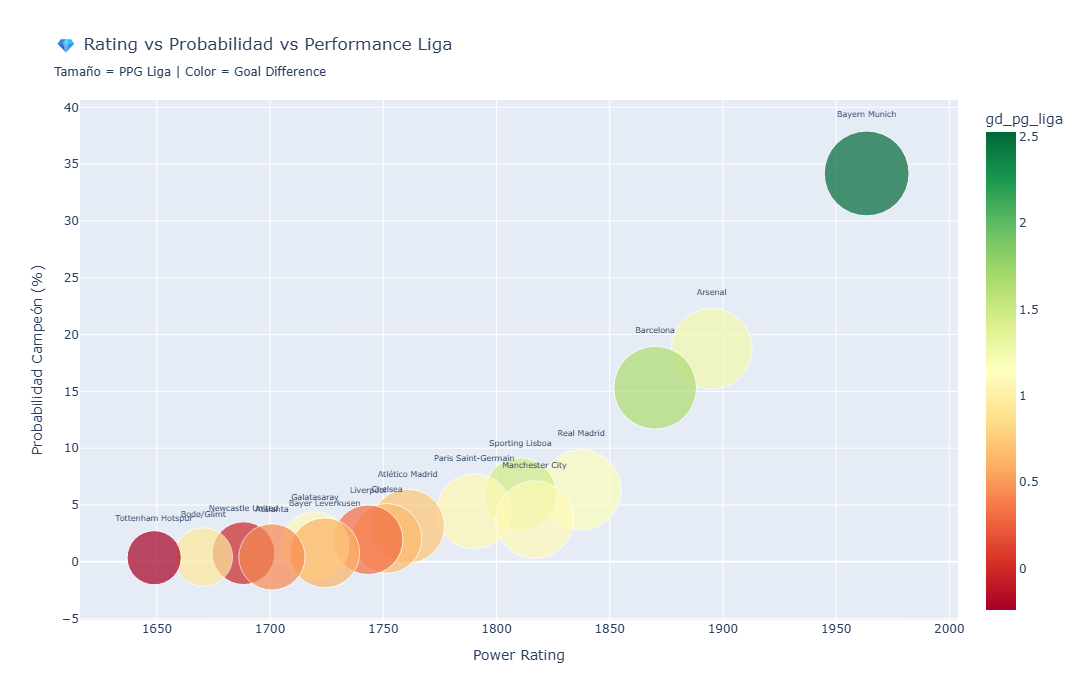

In [8]:
# Merge completo
df_full = df_prob.merge(df_ratings[['Equipo', 'ppg_liga', 'gd_pg_liga']], on='Equipo')

fig_bubble = px.scatter(
    df_full,
    x='Rating',
    y='Prob_Campeon',
    size='ppg_liga',
    color='gd_pg_liga',
    hover_name='Equipo',
    text='Equipo',
    color_continuous_scale='RdYlGn',
    size_max=60,
    title='💎 Rating vs Probabilidad vs Performance Liga<br><sub>Tamaño = PPG Liga | Color = Goal Difference</sub>'
)

fig_bubble.update_traces(
    textposition='top center',
    textfont_size=8
)

fig_bubble.update_layout(
    height=700,
    xaxis_title='Power Rating',
    yaxis_title='Probabilidad Campeón (%)'
)

fig_bubble.show()
fig_bubble.write_html('../visualizations/bubble_3d.html')

## 7. ⚡ WATERFALL CHART - Descomposición de Probabilidad

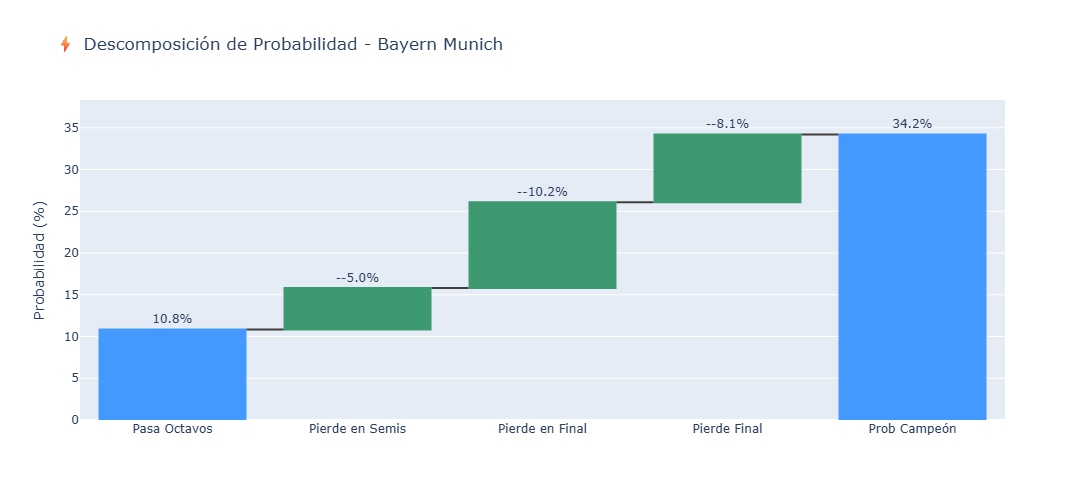

In [9]:
# Para el equipo favorito, mostrar cómo se construye su probabilidad
favorito = df_prob.iloc[0]

# Calcular pérdida de probabilidad en cada ronda
prob_cuartos = favorito['Prob_Cuartos']
prob_semi = favorito['Prob_Semi']
prob_final = favorito['Prob_Final']
prob_campeon = favorito['Prob_Campeon']

# Pérdidas
perdida_semi = prob_cuartos - prob_semi
perdida_final = prob_semi - prob_final
perdida_campeon = prob_final - prob_campeon

fig_waterfall = go.Figure(go.Waterfall(
    name="Probabilidad",
    orientation="v",
    measure=["absolute", "relative", "relative", "relative", "total"],
    x=["Pasa Octavos", "Pierde en Semis", "Pierde en Final", "Pierde Final", "Prob Campeón"],
    textposition="outside",
    text=[f"{prob_cuartos:.1f}%", f"-{perdida_semi:.1f}%", f"-{perdida_final:.1f}%", 
          f"-{perdida_campeon:.1f}%", f"{prob_campeon:.1f}%"],
    y=[prob_cuartos, -perdida_semi, -perdida_final, -perdida_campeon, prob_campeon],
    connector={"line": {"color": "rgb(63, 63, 63)"}},
))

fig_waterfall.update_layout(
    title=f"⚡ Descomposición de Probabilidad - {favorito['Equipo']}",
    showlegend=False,
    height=500,
    yaxis_title="Probabilidad (%)"
)

fig_waterfall.show()
fig_waterfall.write_html('../visualizations/waterfall_favorito.html')

## ✅ Resumen de Visualizaciones Creadas

**7 visualizaciones profesionales:**
1. ✅ Bracket Interactivo
2. ✅ Heatmap de Enfrentamientos
3. ✅ Sankey Diagram - Flujo
4. ✅ Radar Chart - Comparación
5. ✅ Treemap - Concentración
6. ✅ Bubble 3D - Multidimensional
7. ✅ Waterfall - Descomposición

**Todas guardadas en:** `visualizations/`